In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [6]:
df=pd.read_csv("train.csv",usecols=["Age","Fare","Survived"])
df


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [12]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [11]:
df["Age"].fillna(df["Age"].mean(),inplace=True)

C:\Users\Utkarsh Verma\AppData\Local\Temp\ipykernel_36924\2595122914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [27]:
X=df.iloc[:,1:3]
X
Y=df.iloc[:,0]
Y


0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [28]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)



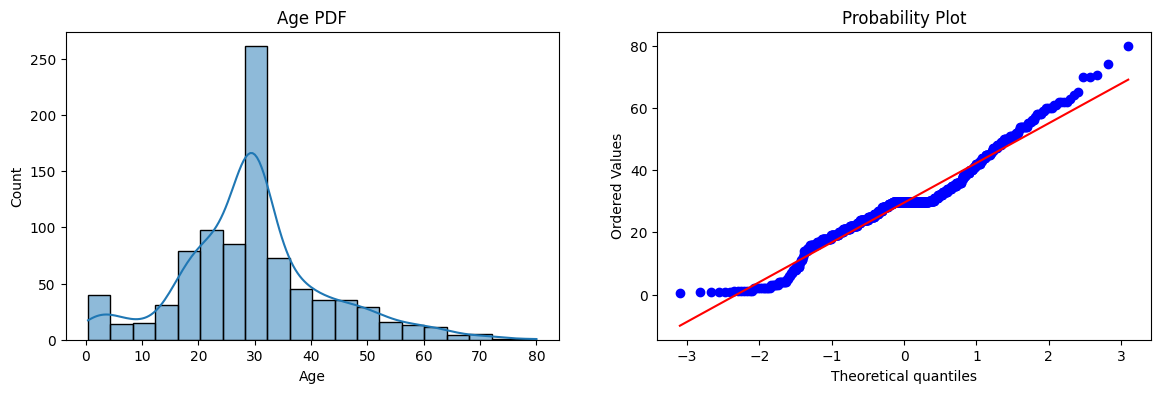

In [60]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(df["Age"],kde=True,binwidth=4)
plt.title("Age PDF")

plt.subplot(122)
stats.probplot(X_train["Age"],dist='norm',plot=plt)
plt.show()


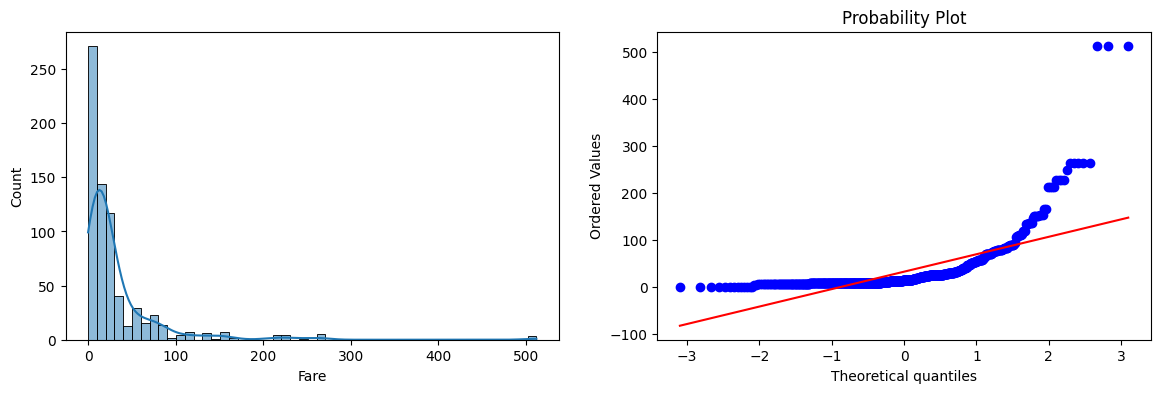

In [73]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'],kde=True,binwidth=10)
plt.subplot(122)
stats.probplot(X_train["Fare"],dist="norm",plot=plt)
plt.show()

In [74]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

In [79]:
clf1.fit(X_train,Y_train)
clf2.fit(X_train,Y_train)

y_pred=clf1.predict(X_test)
y_pred1=clf2.predict(X_test)

print(" Accuracy LR",accuracy_score(Y_test,y_pred))
print(" Accuracy DT",accuracy_score(Y_test,y_pred1))

 Accuracy LR 0.6480446927374302
 Accuracy DT 0.659217877094972


In [84]:
trf=FunctionTransformer(func=np.log1p)


In [89]:
X_train_trans=trf.fit_transform(X_train)
X_test_trans=trf.transform(X_test)


In [93]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

clf1.fit(X_train_trans,Y_train)
clf2.fit(X_train_trans,Y_train)

y_pred=clf1.predict(X_test_trans)
y_pred1=clf2.predict(X_test_trans)

print("accuracy_score",accuracy_score(Y_test,y_pred))
print("accuracy_score",accuracy_score(Y_test,y_pred1))



accuracy_score 0.6815642458100558
accuracy_score 0.6871508379888268


In [99]:
X_transformed=trf.fit_transform(X_train)
clf=LogisticRegression()
clf1=DecisionTreeClassifier()
print("LR",np.mean(cross_val_score(clf,X,Y,scoring="accuracy",cv=10)))
print("DT",np.mean(cross_val_score(clf1,X,Y,scoring="accuracy",cv=10)))

LR 0.6589013732833957
DT 0.6610986267166042
